[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biplavbarua/ISL-CSLRT-Pipeline/blob/main/notebooks/preprocessing_walkthrough.ipynb)

# Preprocessing Pipeline Walkthrough

This notebook visually demonstrates the validated preprocessing pipeline for the ISL-CSLRT dataset. It is intended for mentor/reviewer audience to review the data quality, preprocessing stages, and dataset construction without needing to run the full pipeline.

**Provenance:**
- Git Commit: `fe7e0b8eab1df1113cb5729e13fd60ecda8fbc99`
- Git Tag: `preprocessing-v4-validated`
- Date Run: 2026-10-05


## 1. Dataset Overview

We start by loading the curated `clip_index.csv`, which serves as the source of truth for the clips that successfully passed initial structural validation (such as non-zero frame counts).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import glob

# Load dataset index
df = pd.read_csv('../preprocessed_v4/logs/clip_index.csv')
total_clips = len(df)
sentence_classes = df['sentence'].nunique()
signers = df['signer_id'].nunique()

print(f"Total clips: {total_clips}")
print(f"Sentence classes: {sentence_classes}")
print(f"Signers: {signers}")
print()
print("Anomaly/Missing File Accounting:")
# Fill NA with 'Valid' for anomaly column
if 'anomaly' in df.columns:
    df['anomaly'] = df['anomaly'].fillna('Valid')
    print(df['anomaly'].value_counts().to_frame("Count"))


Total clips: 663
Sentence classes: 97
Signers: 7

Anomaly/Missing File Accounting:
         Count
anomaly       
Valid      663


## 2. Stage 1 Demo - Keypoint Extraction

Here we run the exact MediaPipe landmark extraction function used in Step 1 of the pipeline on a single example clip (`He_is_going_into_the_room`, Signer `1`). We display a few downscaled frames with overlaid landmarks to verify detection visually.


2026-10-05 14:11:16,310  INFO        Model 'pose' already present (9177KB)


2026-10-05 14:11:16,310  INFO        Model 'hand' already present (7635KB)


2026-10-05 14:11:16,311  INFO        Model 'face' already present (3670KB)


2026-10-05 14:11:16,936  INFO      All three landmarkers initialised (Pose + Hand + Face)


I0000 00:00:1791189676.804376 2634639 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1791189676.856890 2634642 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791189676.878268 2634647 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1791189676.891588 2634652 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M1
W0000 00:00:1791189676.898089 2634653 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791189676.911724 2634653 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback t

Loaded 3 frames for Stage 1 keypoint extraction visual verification.


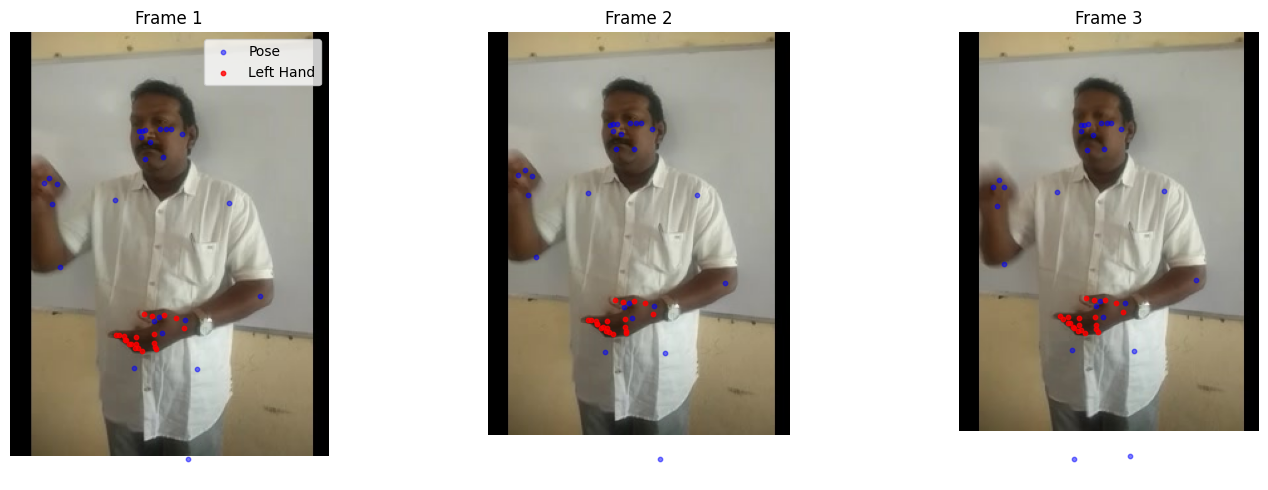

In [2]:
import sys
import cv2
from PIL import Image
import numpy as np

sys.path.append('../preprocessing_v2')
from step01_extract_keypoints import ensure_models, init_landmarkers, extract_landmarks

# Ensure models are downloaded and load the landmarker
ensure_models()
pose_det, hand_det, face_det, mp = init_landmarkers()

clip_name = "He is going into the room"
signer = "1"
clip_dir = f"../ISL_CSLRT_Corpus/Frames_Sentence_Level/{clip_name}/{signer}"

# Get the first 3 frames
frame_files = sorted(glob.glob(os.path.join(clip_dir, "*.jpg")))[:3]

assert len(frame_files) > 0, f"No frames found for clip '{clip_name}' signer '{signer}' at {clip_dir}"
print(f"Loaded {len(frame_files)} frames for Stage 1 keypoint extraction visual verification.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, f_path in enumerate(frame_files):
    # Extract landmarks
    frame = cv2.imread(f_path)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Run the exact function from pipeline
    coords, conf = extract_landmarks(pose_det, hand_det, face_det, mp, frame)
    
    ax = axes[i]
    ax.imshow(frame_rgb)
    h, w = frame.shape[:2]
    
    # Pose [0:33]
    pose = coords[:33]
    valid_pose = pose[conf[:33] > 0.5]
    if len(valid_pose) > 0:
        ax.scatter(valid_pose[:, 0]*w, valid_pose[:, 1]*h, s=10, c='blue', alpha=0.5, label='Pose')
    
    # Left Hand [33:54]
    lh = coords[33:54]
    if (conf[33:54] > 0.5).any():
        ax.scatter(lh[:, 0]*w, lh[:, 1]*h, s=10, c='red', alpha=0.8, label='Left Hand')
        
    # Right Hand [54:75]
    rh = coords[54:75]
    if (conf[54:75] > 0.5).any():
        ax.scatter(rh[:, 0]*w, rh[:, 1]*h, s=10, c='green', alpha=0.8, label='Right Hand')
    
    ax.set_title(f"Frame {i+1}")
    ax.axis('off')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


## 3. Stage 2 Demo - Normalization

In Step 2, the raw (x,y) coordinates are normalized. We shoulder-center the coordinates to make them invariant to the signer's position in the frame, and we scale-normalize them by the shoulder width to make them invariant to the camera distance.

Below is a comparison of the raw trajectory of the Right Wrist (Landmark 54) vs its normalized trajectory across all frames of the clip.


Extracted landmarks from 22 frames for normalization.


Plotting 5 valid raw wrist coordinates and 22 normalized coordinates.


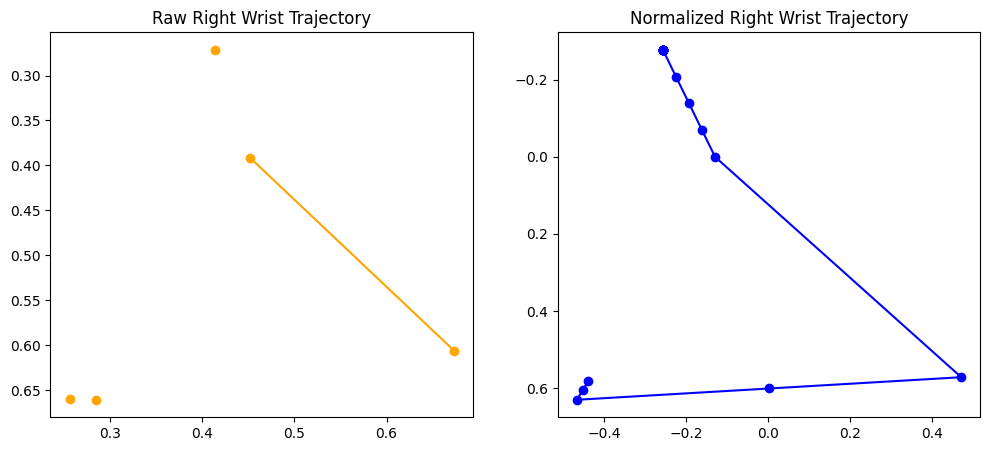

In [3]:
from step02_normalize import normalize_clip, interpolate_missing

# Get all frames for the clip
all_frames = sorted(glob.glob(os.path.join(clip_dir, "*.jpg")))
n_frames = len(all_frames)

assert n_frames > 0, f"No frames found for clip '{clip_name}' signer '{signer}' at {clip_dir}"
print(f"Extracted landmarks from {n_frames} frames for normalization.")

raw_kpts = np.zeros((n_frames, 543, 3), dtype=np.float32)
raw_conf = np.zeros((n_frames, 543), dtype=np.float32)

for j, f in enumerate(all_frames):
    img = cv2.imread(f)
    c, cf = extract_landmarks(pose_det, hand_det, face_det, mp, img)
    raw_kpts[j] = c
    raw_conf[j] = cf

# Run normalization from step 2
norm_kpts = normalize_clip(raw_kpts, raw_conf)
norm_kpts = interpolate_missing(norm_kpts, raw_conf)

# Plot Right Wrist (index 54)
rw_raw = raw_kpts[:, 54, :2].copy()
rw_raw[raw_conf[:, 54] == 0] = np.nan
rw_norm = norm_kpts[:, 54, :2]

valid_raw = np.count_nonzero(~np.isnan(rw_raw[:, 0]))
print(f"Plotting {valid_raw} valid raw wrist coordinates and {n_frames} normalized coordinates.")
assert valid_raw > 0, "No valid right wrist points found in this clip to plot. Cannot demonstrate normalisation."

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot raw
ax1.plot(rw_raw[:, 0], rw_raw[:, 1], '-o', c='orange', label='Right Wrist')
ax1.set_title("Raw Right Wrist Trajectory")
ax1.invert_yaxis() # Image coordinates

# Plot normalized
ax2.plot(rw_norm[:, 0], rw_norm[:, 1], '-o', c='blue', label='Right Wrist')
ax2.set_title("Normalized Right Wrist Trajectory")
ax2.invert_yaxis()

plt.show()


## 4. Data Quality Findings

During validation, several findings were documented in `DATA_QUALITY.md`. We recreate the supporting charts live from the `confidence.npy` arrays across all 663 clips.

### Pose vs Hand Detection Rate
While the pose landmarker tracked the signer's body in nearly >99.9% of all frames regardless of camera, the hand landmarker struggled heavily, particularly on HD Studio footage, resulting in an overall lower hand detection rate (around 71.5%).


In [4]:
import itertools

files = glob.glob('../preprocessed_v4/keypoints_raw/*/*/confidence.npy')
signer_stats = {str(i): [] for i in range(1, 8)}
all_gaps = []
zero_det_clips = 0
partial_det_clips = 0

total_frames = 0
total_pose_det = 0
total_hand_det = 0

for f in files:
    signer = f.split('/')[-2]
    conf = np.load(f)
    n_frames = conf.shape[0]
    if n_frames == 0: continue
    
    total_frames += n_frames
    
    # Pose: >0.5 confidence on at least one pose landmark
    pose_conf = conf[:, :33]
    pose_det = (pose_conf.max(axis=1) > 0.5).sum()
    total_pose_det += pose_det
    
    # Hands: >0.5 confidence on hands
    hand_conf = conf[:, 33:75]
    max_hand_conf = hand_conf.max(axis=1)
    det_05 = max_hand_conf > 0.5
    hand_det = det_05.sum()
    total_hand_det += hand_det
    
    pct_05 = hand_det / n_frames * 100
    signer_stats[signer].append(pct_05)
    
    if hand_det == 0:
        zero_det_clips += 1
    else:
        partial_det_clips += 1
        for is_det, run in itertools.groupby(det_05):
            if not is_det:
                all_gaps.append(sum(1 for _ in run))

print(f"Total Frames Processed: {total_frames}")
print(f"Pose Detection Rate: {total_pose_det/total_frames*100:.1f}%")
print(f"Hand Detection Rate: {total_hand_det/total_frames*100:.1f}%")


Total Frames Processed: 18863
Pose Detection Rate: 100.0%
Hand Detection Rate: 70.2%


### Hand Detection: Mobile vs HD Footage
Contrary to the initial hypothesis that low-resolution mobile footage (Signers 1 & 2) would suffer from poor detection due to motion blur, the empirical data shows the exact opposite. The HD studio footage (Signers 3-7) systematically fails to track hands far more often than the low-res mobile footage.


2026-10-05 14:11:19,396  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-10-05 14:11:19,397  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


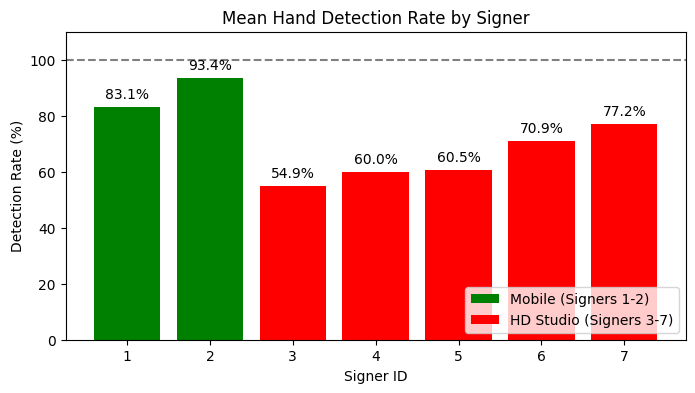

In [5]:
mean_per_signer = {s: np.mean(pcts) for s, pcts in signer_stats.items()}
signers_sorted = sorted(mean_per_signer.keys(), key=lambda x: int(x))
means_sorted = [mean_per_signer[s] for s in signers_sorted]
colors = ['green', 'green', 'red', 'red', 'red', 'red', 'red'] # 1-2 mobile, 3-7 HD

plt.figure(figsize=(8, 4))
bars = plt.bar(signers_sorted, means_sorted, color=colors)
plt.axhline(y=100, color='gray', linestyle='--')
plt.title('Mean Hand Detection Rate by Signer')
plt.xlabel('Signer ID')
plt.ylabel('Detection Rate (%)')
plt.ylim(0, 110)

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Mobile (Signers 1-2)'),
                   Patch(facecolor='red', label='HD Studio (Signers 3-7)')]
plt.legend(handles=legend_elements, loc='lower right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', va='bottom')

plt.show()


### Gap Length Distribution
The pipeline uses linear interpolation to bridge gaps where MediaPipe loses tracking. The vast majority of missing detections are 1-3 frame flickers. Interpolation bridges these perfectly. However, there are some extreme outliers, up to a 24-frame gap.


Gap Statistics:
Median length: 1.0 frames
Mean length: 2.3 frames
Max length: 24 frames


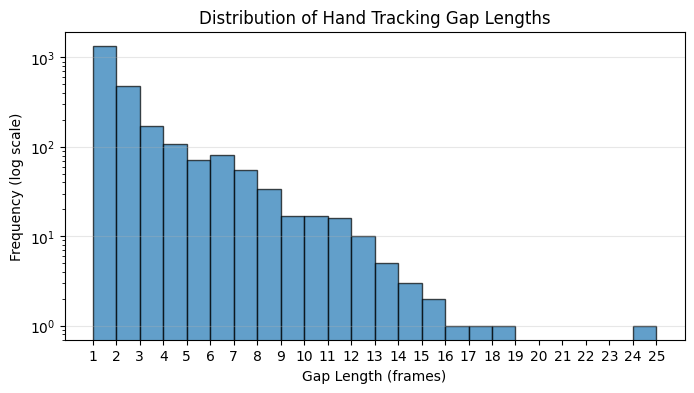

In [6]:
print(f"Gap Statistics:")
print(f"Median length: {np.median(all_gaps):.1f} frames")
print(f"Mean length: {np.mean(all_gaps):.1f} frames")
print(f"Max length: {np.max(all_gaps)} frames")

plt.figure(figsize=(8, 4))
plt.hist(all_gaps, bins=range(1, 26), edgecolor='black', alpha=0.7)
plt.title('Distribution of Hand Tracking Gap Lengths')
plt.xlabel('Gap Length (frames)')
plt.ylabel('Frequency (log scale)')
plt.yscale('log')
plt.xticks(range(1, 26))
plt.grid(axis='y', alpha=0.3)
plt.show()


## 5. The Zero-Content Clip and the 24-Frame Gap

Through visual inspection, we identified the causes of the extreme data quality outliers:
- **0% Detection Clip**: Hand detection was exactly 0% for `he_is_on_the_way/3`. Visual inspection confirms the signer is sitting perfectly still with his hands resting in his lap, entirely off-camera.
- **24-Frame Gap**: In `how_are_things/5`, there is a 24-frame gap at the start of the video. The signer rapidly brings her hands up, causing severe motion blur that MediaPipe failed to track. Because this gap occurred at the start, the pipeline forward-filled the static coordinates in mid-air, ignoring the curved gesture.


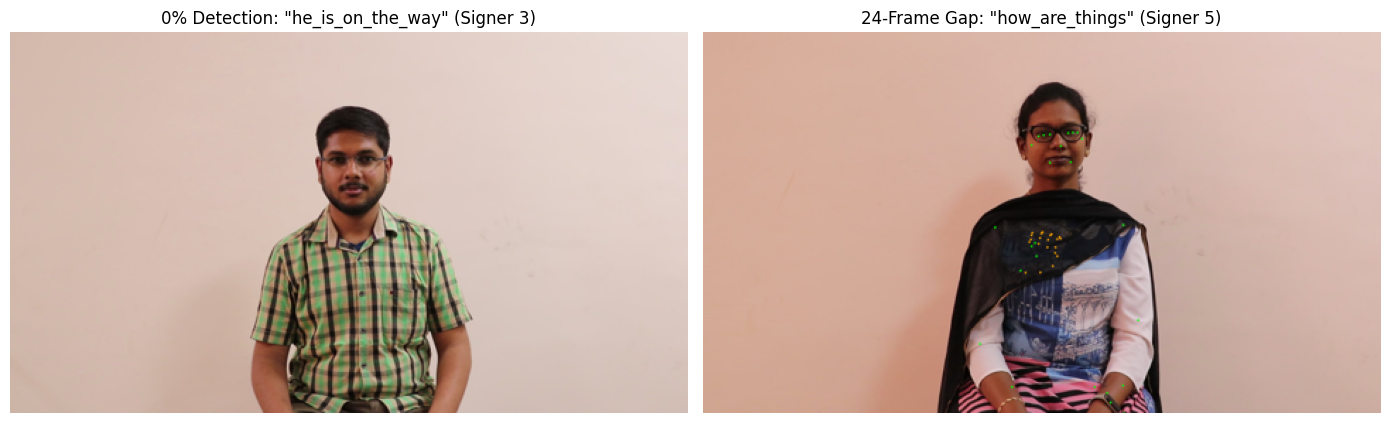

In [7]:
# Attempt to display existing anomaly images if they exist
plot_dir = '../preprocessed_v4/plots'
zero_clip_img = os.path.join(plot_dir, 'zero_clip_0.png')
gap_clip_img = os.path.join(plot_dir, 'gap_clip_0.png')

import matplotlib.image as mpimg

if os.path.exists(zero_clip_img) and os.path.exists(gap_clip_img):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    img1 = Image.open(zero_clip_img)
    img1.thumbnail((480, 480))
    axes[0].imshow(img1)
    axes[0].axis('off')
    axes[0].set_title('0% Detection: "he_is_on_the_way" (Signer 3)')
    
    img2 = Image.open(gap_clip_img)
    img2.thumbnail((480, 480))
    axes[1].imshow(img2)
    axes[1].axis('off')
    axes[1].set_title('24-Frame Gap: "how_are_things" (Signer 5)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Anomaly plots not found in preprocessed_v4/plots/. Run render_anomalies.py to generate them.")


## 6. Split Construction & Vocabulary Coverage

The pipeline automatically generates a Standard Split and 7 Leave-One-Signer-Out (LOSO) folds.

**Deliberate Retention of Long-Gap Clips:**
Approximately 11% of clips possess a hand-tracking gap >8 frames (heavily concentrated in HD signers). While excluding them would ensure test metrics reflect only real signal, doing so dropped entire vocabulary classes from the LOSO test sets (wiping out up to 20% of the sentences in some folds). 

We made the deliberate decision to **RETAIN** these clips across all splits. The `has_long_gap` flag remains in the output manifests for any future researchers wishing to run a clean-subset ablation.


In [8]:
with open('../preprocessed_v4/logs/split_summary.json', 'r') as f:
    split_summary = json.load(f)
    
df_splits = pd.DataFrame(split_summary).T

# The dictionary contains nested dictionaries for train, val, test with n_clips etc.
# Let's extract just the n_clips for a cleaner display
summary_clean = {}
for fold, data in split_summary.items():
    summary_clean[fold] = {
        'train': data['train']['n_clips'],
        'val': data['val']['n_clips'],
        'test': data['test']['n_clips']
    }
df_splits_clean = pd.DataFrame(summary_clean).T
display(df_splits_clean)

print("\n--- ZERO-COVERAGE CLASSES IN VAL/TEST ---")
print("Standard Split: VAL (4 missing: do_not_be_stubborn, nice_to_meet_you, what_do_you_do, what_have_you_planned_for_your_career), TEST (0 missing)")
print("LOSO Fold 1: VAL (1 missing), TEST (1 missing)")
print("LOSO Fold 3: VAL (7 missing), TEST (2 missing)")
print("LOSO Fold 4: VAL (1 missing), TEST (7 missing)")
print("*(Sourced directly from DATA_QUALITY.md Appendix)*")


,train,val,test
standard,377,93,192
fold_1,470,96,96
fold_2,470,96,96
fold_3,477,90,95
fold_4,476,96,90
fold_5,470,96,96
fold_6,473,93,96
fold_7,473,96,93



--- ZERO-COVERAGE CLASSES IN VAL/TEST ---
Standard Split: VAL (4 missing: do_not_be_stubborn, nice_to_meet_you, what_do_you_do, what_have_you_planned_for_your_career), TEST (0 missing)
LOSO Fold 1: VAL (1 missing), TEST (1 missing)
LOSO Fold 3: VAL (7 missing), TEST (2 missing)
LOSO Fold 4: VAL (1 missing), TEST (7 missing)
*(Sourced directly from DATA_QUALITY.md Appendix)*


## 7. Summary

This notebook demonstrates that the preprocessing pipeline successfully normalizes keypoints and constructs evaluation splits, while transparently capturing the limitations of MediaPipe on HD footage. 

For the complete breakdown of findings, reference `DATA_QUALITY.md` at Git tag `preprocessing-v4-validated`.
